# The Month the Countryside Switches On

**Mapping *when*, not *how much*, over the Doñana berry belt**

The strawberry and berry farms between Huelva and Doñana are among the biggest in Europe,
and they run on a calendar: plastic goes over the fields in autumn, picking runs from late
winter into June, and by July the fields are bare. Tens of thousands of seasonal workers
follow that calendar, and part of them live in informal settlements in the pine woods
between the greenhouses — occupied for half the year, empty for the other half.

Can a radiometer that sees the Earth at night in 500 m pixels detect a place switching on
for the picking season?

The companion notebook [Joining DMSP and VIIRS (Doñana)](11_donana_lights.ipynb) already
answered a version of that question in the negative: Matalascañas triples its population
in August and its brightness moves by 7%, because street lighting burns whether or not
anybody is home. But a camp is the opposite case. It is not a modulation of lamps that are
already there — it is **light added to a dark background**, with nothing at all in the off
season. A different physical problem, and it deserves its own test.

To run it we need the thing notebook 11 deliberately did not make: a **map** of the month
of maximum, pixel by pixel, over the farming country rather than over the reserve. This
notebook makes it — and the first map it produces is wrong, in a way that turns out to be
worth more than the answer.

What is used here: `get_peak_period()` with a `composite=` of our own, and
`get_peak_statistics()` for the circular summary across years. Both are cheap — VIIRS is
one image per month, so the whole notebook is a few hundred images.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geemap.conversion')

import ee
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

from ndvi2gif import NdviSeasonality

# ee.Authenticate()          # only the first time
PROJECT = 'your-project-id'
ee.Initialize(project=PROJECT)
print('✓ Earth Engine initialised')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


✓ Earth Engine initialised


The ROI is not the reserve but the **farming country around it**: the berry belt of Lucena
del Puerto, Moguer, Bonares and Palos, the county town of Almonte, the pilgrimage village
of El Rocío, the resorts of Mazagón and Matalascañas, and the dunes, pine woods and marsh
in between. A rectangle is used on purpose — the question is about a landscape, not about
a protected boundary, and a rectangle keeps the maps below easy to read and to reproduce.

In [2]:
COMARCA = ee.Geometry.Rectangle([-6.98, 36.95, -6.35, 37.38])
YEARS = range(2014, 2026)

monthly = NdviSeasonality(roi=COMARCA, sat='VIIRS', index='avg_rad', key='mean',
                          periods=12, start_year=2014, end_year=2025)
MONTHS = monthly.period_names                      # 'january' ... 'december'
SHORT = [month[:3].title() for month in MONTHS]

print('%.0f km2, %d monthly composites' % (COMARCA.area(1000).getInfo() / 1e6,
                                           12 * len(YEARS)))

There we go again...
VIIRS DNB monthly nighttime lights (2014-present, ~500m resolution)


2669 km2, 144 monthly composites


Five places will be referred to throughout, so they are defined once. The three **dark
references** are the heart of section 3: patches with no street lighting of any kind, one
of them not even land.

In [3]:
PLACES = {'Almonte': (-6.5164, 37.2606),         # county town, lived in all year
          'El Rocío': (-6.4869, 37.1332),        # the pilgrimage village
          'Matalascañas': (-6.5497, 36.9906),    # beach resort, summer population
          'Moguer': (-6.8378, 37.2753),          # town at the edge of the berry belt
          'Lucena del Puerto': (-6.7272, 37.2703)}   # the heart of the berry belt

DARK = {'open sea': ee.Geometry.Rectangle([-6.85, 36.60, -6.55, 36.75]),
        'Abalario pine': ee.Geometry.Rectangle([-6.66, 37.08, -6.60, 37.14]),
        'marisma': ee.Geometry.Rectangle([-6.42, 37.00, -6.34, 37.06])}

# A month is a direction on a circle, so its ramp has to close on itself: twelve
# hues at constant lightness, January cool and July warm. Neighbouring months look
# alike on purpose — May and June *are* alike — so the exact counts are always given
# by a bar chart next to the map rather than read off the colours.
RING = ['d87880', 'd57f57', 'c38c37', 'a49c38', '77a95b', '3eaf86',
        '00afaf', '26a7d0', '639be1', '918ddf', 'b481cb', 'cc79a9']
CYCLE = [RING[(i + 8) % 12] for i in range(12)]
LIGHTS = ['000000', '2c115f', 'b63679', 'fe9f6d', 'fcfdbf']
HUES = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00']
INK, MUTED = '#222222', '#777777'

plt.style.use('default')            # geemap leaves a style behind on import
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#cccccc', 'axes.labelcolor': INK,
                     'axes.facecolor': 'white', 'figure.facecolor': 'white',
                     'savefig.facecolor': 'white', 'axes.grid': False,
                     'text.color': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
                     'grid.color': '#e8e8e8', 'grid.linewidth': 0.8,
                     'font.size': 9, 'figure.dpi': 110})

Two helpers do all the drawing: one turns an Earth Engine image into a thumbnail array,
the other places a town on it. Because the region is a lat/lon rectangle and the default
thumbnail projection is EPSG:4326, degrees map to pixels linearly.

In [4]:
PARK = (ee.FeatureCollection('WCMC/WDPA/current/polygons')
        .filterBounds(COMARCA)
        .filter(ee.Filter.And(ee.Filter.eq('NAME', 'Doñana'),
                              ee.Filter.eq('DESIG_ENG', 'Nacional Park'))))
OUTLINE = ee.Image().byte().paint(PARK, 1, 1).selfMask().visualize(palette=['9a9a9a'])

COMARCA_BOX = (-6.98, 36.95, -6.35, 37.38)


def thumbnail(image, vis, region=COMARCA, dimensions=760, outline=True):
    # an EE image as an RGBA array, with the National Park drawn on it
    picture = image.visualize(**vis)
    if outline:
        picture = picture.blend(OUTLINE)
    url = picture.getThumbURL({'region': region, 'dimensions': dimensions,
                               'format': 'png'})
    return np.array(Image.open(BytesIO(urlopen(url).read())))


HALO = [pe.withStroke(linewidth=2.2, foreground='white')]


def label_places(ax, array, names=PLACES, region=COMARCA_BOX, colour='#1b1b1b'):
    # put the towns on a thumbnail drawn over (west, south, east, north); the
    # halo keeps them readable over a dark pixel and over a masked white one
    west, south, east, north = region
    height, width = array.shape[:2]
    for name, (lon, lat) in names.items():
        if not (west < lon < east and south < lat < north):
            continue
        x = (lon - west) / (east - west) * width
        y = (north - lat) / (north - south) * height
        ax.plot(x, y, 'o', ms=3.5, mfc='none', mec=colour, mew=1.2,
                path_effects=HALO)
        right = x > 0.72 * width               # keep the label inside the panel
        ax.annotate(name, (x, y), xytext=(-6 if right else 6, 3),
                    textcoords='offset points', ha='right' if right else 'left',
                    fontsize=7.5, color=colour, path_effects=HALO)


def month_legend(ax, colours=CYCLE, labels=SHORT):
    # a twelve-cell strip that says which colour is which month
    for i, colour in enumerate(colours):
        ax.add_patch(mpl.patches.Rectangle((i, 0), 0.92, 1, color='#' + colour))
        ax.text(i + 0.46, -0.45, labels[i], ha='center', va='top', fontsize=7.5,
                color=MUTED)
    ax.set_xlim(-0.2, 12.1)
    ax.set_ylim(-1.6, 1.1)
    ax.axis('off')

## 2. The first map, and why it cannot be right

`get_peak_period()` asks each pixel which of the twelve months holds its maximum.
`mask_below=0.5` drops the pixels whose brightest month never reaches 0.5 nW/cm²/sr — the
timing of a pixel with no signal is the timing of its noise.

In [5]:
naive = monthly.get_peak_period(mask_below=0.5, return_peak_value=True,
                               return_ties=True)
print(naive.bandNames().getInfo())

Year 2014: 12/12 periods with data using avg_rad index


Year 2015: 12/12 periods with data using avg_rad index


Year 2016: 12/12 periods with data using avg_rad index


Year 2017: 12/12 periods with data using avg_rad index


Year 2018: 12/12 periods with data using avg_rad index


...

Year 2022: 12/12 periods with data using avg_rad index


Year 2023: 12/12 periods with data using avg_rad index


Year 2024: 12/12 periods with data using avg_rad index


Year 2025: 12/12 periods with data using avg_rad index


['peak_period', 'peak_value', 'ties']


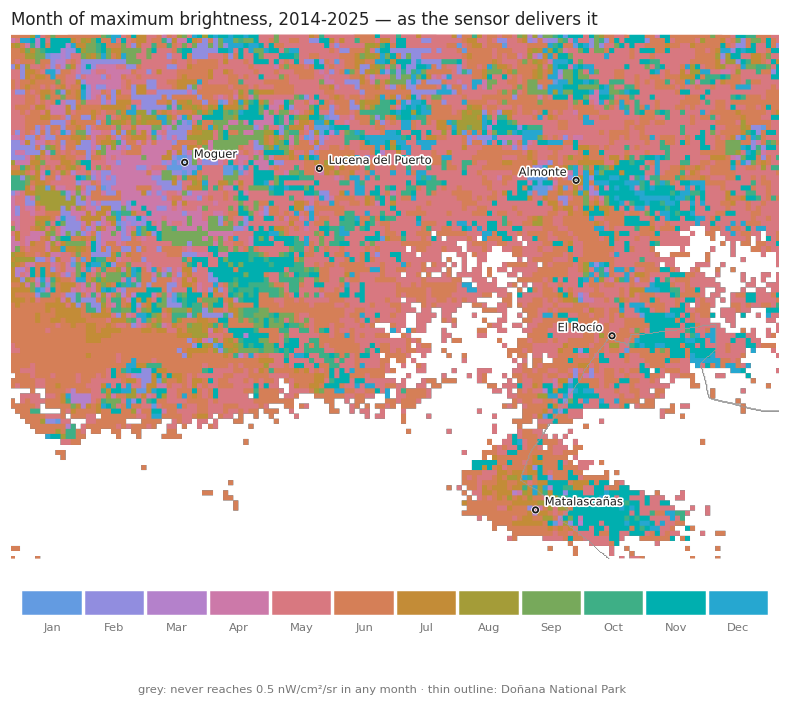

In [6]:
MONTH_VIS = {'min': 1, 'max': 12, 'palette': CYCLE}
naive_map = thumbnail(naive.select('peak_period'), MONTH_VIS)

fig = plt.figure(figsize=(9, 7.4))
grid = fig.add_gridspec(2, 1, height_ratios=[16, 1.7], hspace=0.06)
ax = fig.add_subplot(grid[0])
ax.set_facecolor('#f2f2f0')
ax.imshow(naive_map)
label_places(ax, naive_map)
ax.set_title('Month of maximum brightness, 2014-2025 — as the sensor delivers it',
             loc='left', fontsize=11)
ax.axis('off')
month_legend(fig.add_subplot(grid[1]))
fig.text(0.5, 0.055, 'grey: never reaches 0.5 nW/cm²/sr in any month · '
         'thin outline: Doñana National Park', ha='center', fontsize=7.5, color=MUTED)
plt.show()

Almost the whole countryside is the same colour, and the colour is May and June. Dunes,
pine woods, the marsh, ploughed fields — surfaces with no lamp anywhere near them —
apparently share their brightest night of the year with the pilgrimage village. Counting
the pixels makes the size of the problem explicit.

In [7]:
VPROJ = ee.Image(ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
                 .first()).projection()


def month_counts(peak, region=COMARCA):
    # pixels per peak month, counted on the native VIIRS grid
    counts = (peak.select('peak_period').reproject(VPROJ)
              .reduceRegion(ee.Reducer.frequencyHistogram(), region, 463.83,
                            maxPixels=1e9).getInfo()['peak_period'])
    series = pd.Series({int(float(k)): v for k, v in counts.items()})
    return series.reindex(range(1, 13)).fillna(0).round().astype(int).set_axis(SHORT)


naive_counts = month_counts(naive)
print('%d pixels lit; %.0f%% of them peak in May or June'
      % (naive_counts.sum(),
         100 * naive_counts[['May', 'Jun']].sum() / naive_counts.sum()))
naive_counts.to_frame('pixels').T

11193 pixels lit; 60% of them peak in May or June


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
pixels,67,523,67,494,3494,3233,631,236,463,431,1091,463


A composite carries no fixed projection, so the histogram is taken after `reproject()`
onto the VIIRS grid. Without it Earth Engine resamples and reports fractional counts for
month numbers no pixel actually holds — a trap worth remembering whenever a categorical
composite is counted.

Three out of five lit pixels reach their maximum in May or June. That is not a fact about
Doñana. It is a fact about the product.

## 3. Three dark places that agree with each other

The test is simple: take patches that share nothing except the sky above them and see
whether their seasonal cycles match. Open sea forty kilometres offshore, the pine and
scrub of El Abalario, and the marsh — no street lighting in any of them, three different
surfaces, three different albedos.

In [8]:
VIIRS = (ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
         .select('avg_rad').filterDate('2014-01-01', '2026-01-01'))

climatology = ee.Image.cat([
    VIIRS.filter(ee.Filter.calendarRange(m, m, 'month')).mean().rename(MONTHS[m - 1])
    for m in range(1, 13)])

rows = [ee.Feature(None, {'place': name}).set(
            climatology.reduceRegion(ee.Reducer.median(), geometry, 463.83,
                                     maxPixels=1e9))
        for name, geometry in DARK.items()]
background = pd.DataFrame([f['properties'] for f in
                           ee.FeatureCollection(rows).getInfo()['features']])
background = background.set_index('place')[MONTHS].T.set_axis(SHORT)
background.round(3)

place,open sea,Abalario pine,marisma
Jan,0.275,0.375,0.342
Feb,0.304,0.387,0.343
Mar,0.273,0.340,0.306
Apr,0.258,0.346,0.299
May,0.351,0.452,0.407
Jun,0.367,0.452,0.405
Jul,0.305,0.377,0.348
Aug,0.262,0.354,0.306
Sep,0.270,0.354,0.305
Oct,0.316,0.404,0.355


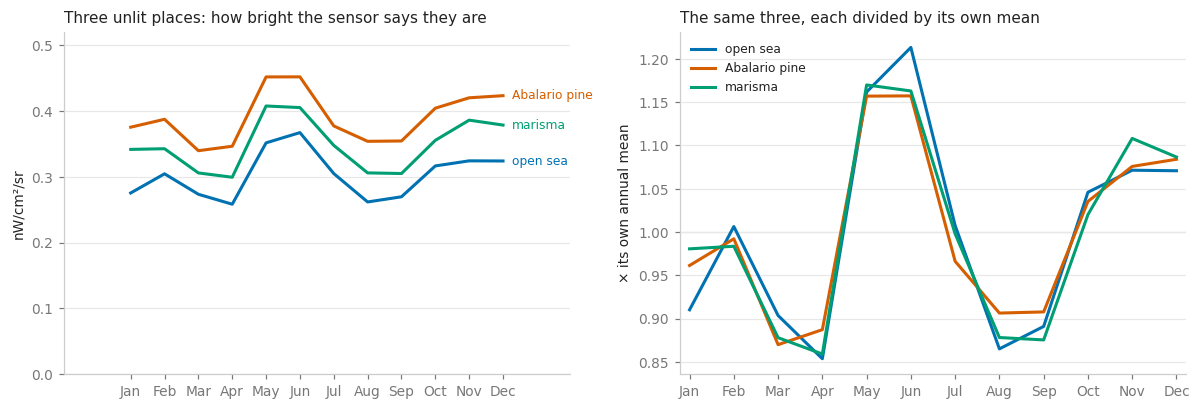

In [9]:
relative = background / background.mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for (name, values), hue in zip(background.items(), HUES):
    axes[0].plot(SHORT, values, '-', lw=2, color=hue)
    axes[0].annotate(name, (11, values.iloc[-1]), xytext=(6, 0),
                     textcoords='offset points', fontsize=8, color=hue, va='center')
axes[0].set_ylabel('nW/cm²/sr')
axes[0].set_ylim(0, 0.52)
axes[0].set_title('Three unlit places: how bright the sensor says they are', loc='left',
                  fontsize=10)

for (name, values), hue in zip(relative.items(), HUES):
    axes[1].plot(SHORT, values, '-', lw=2, color=hue, label=name)
axes[1].axhline(1, color='#cccccc', lw=0.8, zorder=0)
axes[1].set_ylabel('× its own annual mean')
axes[1].set_title('The same three, each divided by its own mean', loc='left', fontsize=10)
axes[1].legend(frameon=False, fontsize=8, loc='upper left')

for ax in axes:
    ax.grid(axis='y', lw=0.8)
    ax.set_axisbelow(True)
axes[0].margins(x=0.18)
axes[1].margins(x=0.02)
plt.tight_layout()

The left panel shows three different levels: the pine woods sit higher than the marsh, and
both sit higher than the sea, which is what three different surfaces under the same sky
should do. The right panel shows that the *shape* is the same in all three within a few
per cent — a trough in March and April, a peak in May and June about 15% above the annual
mean, a smaller rise in November and December.

Nothing on the ground is shared by an ocean, a pine wood and a salt marsh. The cycle is
therefore in the instrument, not in the landscape.

The cause is in the name of the product. `VCMSLCFG` is the **stray-light corrected**
monthly composite: rather than discard the nights when sunlight scattered into the
sensor's field of view — which at this latitude would empty out most of May, June and July
— it keeps them and models the contamination away. The model leaves a residue, and the
residue is largest when the nights are shortest, at the June solstice. The alternative
product, `VCMCFG`, discards those nights instead and has a cleaner background at the price
of missing months.

The background is not stable between years either.

In [10]:
dark = NdviSeasonality(roi=DARK['open sea'], sat='VIIRS', index='avg_rad', key='mean',
                       periods=12, start_year=2014, end_year=2025)

sea = dark.get_year_composite().toList(12)
rows = [ee.Feature(None, {'year': year}).set(
            ee.Image(sea.get(i)).reduceRegion(ee.Reducer.median(), DARK['open sea'],
                                              463.83, maxPixels=1e9))
        for i, year in enumerate(YEARS)]
offsets = pd.DataFrame([f['properties'] for f in
                        ee.FeatureCollection(rows).getInfo()['features']])
offsets = offsets.set_index('year')[MONTHS].set_axis(SHORT, axis=1)
offsets.round(2)

There we go again...
VIIRS DNB monthly nighttime lights (2014-present, ~500m resolution)


Year 2014: 12/12 periods with data using avg_rad index


Year 2015: 12/12 periods with data using avg_rad index


Year 2016: 12/12 periods with data using avg_rad index


Year 2017: 12/12 periods with data using avg_rad index


...

Year 2022: 12/12 periods with data using avg_rad index


Year 2023: 12/12 periods with data using avg_rad index


Year 2024: 12/12 periods with data using avg_rad index


Year 2025: 12/12 periods with data using avg_rad index


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2014,0.15,0.18,0.16,0.09,0.17,0.15,0.11,0.18,0.15,0.17,0.03,0.30
2015,0.19,0.32,0.13,0.07,0.18,0.05,0.07,0.05,0.05,0.07,0.16,0.17
2016,0.12,0.16,0.07,0.09,0.13,0.12,0.03,0.09,0.07,0.12,0.18,0.10
2017,0.17,0.33,0.22,0.22,0.37,0.27,0.25,0.25,0.29,0.41,0.34,0.33
2018,0.32,0.24,0.27,0.24,0.35,0.27,0.28,0.21,0.29,0.29,0.31,0.23
2019,0.16,0.19,0.20,0.29,0.31,0.29,0.22,0.19,0.25,0.32,0.33,0.32
2020,0.14,0.32,0.29,0.28,0.40,0.48,0.34,0.31,0.33,0.34,0.40,0.45
2021,0.42,0.42,0.33,0.33,0.39,0.54,0.45,0.42,0.27,0.31,0.33,0.47
2022,0.34,0.29,0.32,0.34,0.48,0.58,0.47,0.27,0.35,0.32,0.40,0.34


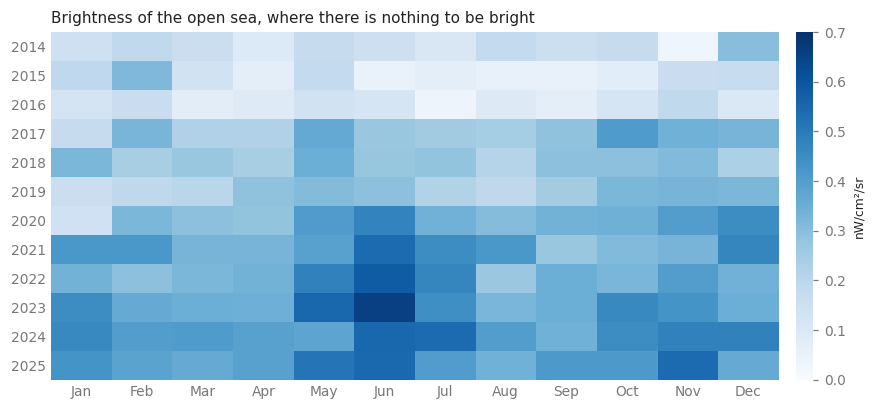

In [11]:
fig, ax = plt.subplots(figsize=(8.6, 3.8))
image = ax.imshow(offsets.values, cmap='Blues', aspect='auto', vmin=0, vmax=0.7)
ax.set_xticks(range(12))
ax.set_xticklabels(SHORT)
ax.set_yticks(range(len(offsets)))
ax.set_yticklabels(offsets.index)
ax.set_title('Brightness of the open sea, where there is nothing to be bright',
             loc='left', fontsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
bar = fig.colorbar(image, ax=ax, pad=0.02)
bar.set_label('nW/cm²/sr', fontsize=8)
bar.outline.set_visible(False)
plt.tight_layout()

Read it in two directions. Across a row, the June column is the darkest: the seasonal
residue again. Down a column, the whole table darkens towards the bottom — the empty ocean
roughly triples between 2014 and 2025, the same drift notebook 11 measured over the same
water. Any correction therefore has to be made **per month and per year**, not once.

## 4. Subtracting the background

The correction is one subtraction: from every monthly band of every year, take away what
the sea read that same month of that same year. `get_peak_period()` accepts a `composite=`
of twelve bands in place of the one it would build itself, which is exactly what a
corrected stack is.

In [12]:
composites = monthly.get_year_composite().toList(12)

corrected = []
for i, year in enumerate(YEARS):
    floor = ee.Image.constant([float(offsets.loc[year, m]) for m in SHORT])
    corrected.append(ee.Image(composites.get(i)).subtract(floor.rename(MONTHS))
                     .rename(MONTHS).set('year', year))

typical = ee.ImageCollection(corrected).median().rename(MONTHS)
peak = monthly.get_peak_period(composite=typical, mask_below=0.5,
                               return_peak_value=True, return_ties=True)
counts = month_counts(peak)

print('%d pixels lit; %.0f%% of them peak in May or June'
      % (counts.sum(), 100 * counts[['May', 'Jun']].sum() / counts.sum()))

Year 2014: 12/12 periods with data using avg_rad index


Year 2015: 12/12 periods with data using avg_rad index


Year 2016: 12/12 periods with data using avg_rad index


Year 2017: 12/12 periods with data using avg_rad index


Year 2018: 12/12 periods with data using avg_rad index


...

Year 2022: 12/12 periods with data using avg_rad index


Year 2023: 12/12 periods with data using avg_rad index


Year 2024: 12/12 periods with data using avg_rad index


Year 2025: 12/12 periods with data using avg_rad index


5331 pixels lit; 19% of them peak in May or June


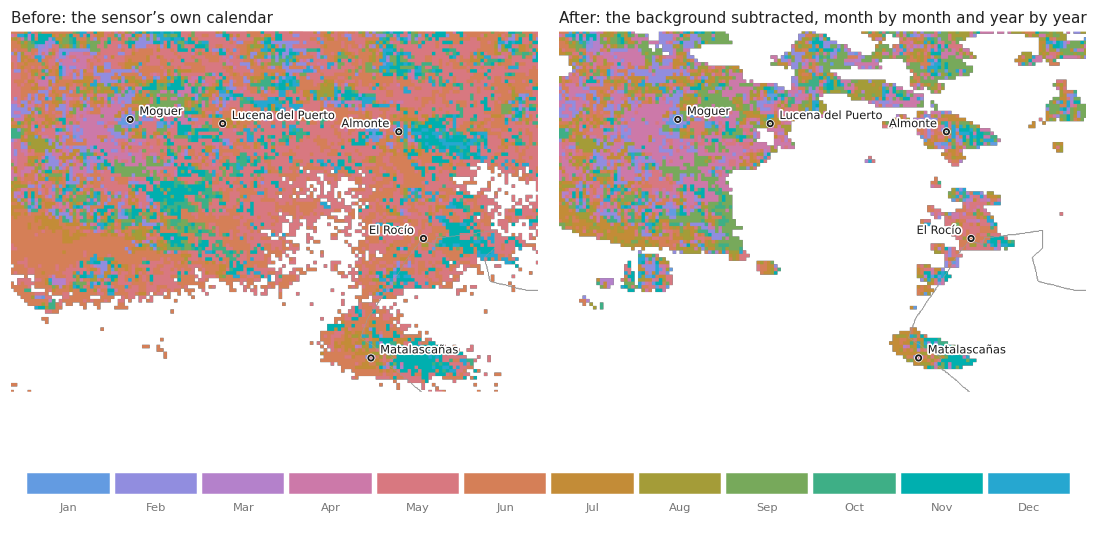

In [13]:
peak_map = thumbnail(peak.select('peak_period'), MONTH_VIS)

fig = plt.figure(figsize=(12.6, 6.6))
grid = fig.add_gridspec(2, 2, height_ratios=[16, 1.7], hspace=0.05, wspace=0.04)
panels = [(naive_map, 'Before: the sensor’s own calendar'),
          (peak_map, 'After: the background subtracted, month by month and year by year')]

for column, (array, title) in enumerate(panels):
    ax = fig.add_subplot(grid[0, column])
    ax.set_facecolor('#f2f2f0')
    ax.imshow(array)
    label_places(ax, array)
    ax.set_title(title, loc='left', fontsize=10)
    ax.axis('off')
month_legend(fig.add_subplot(grid[1, :]))

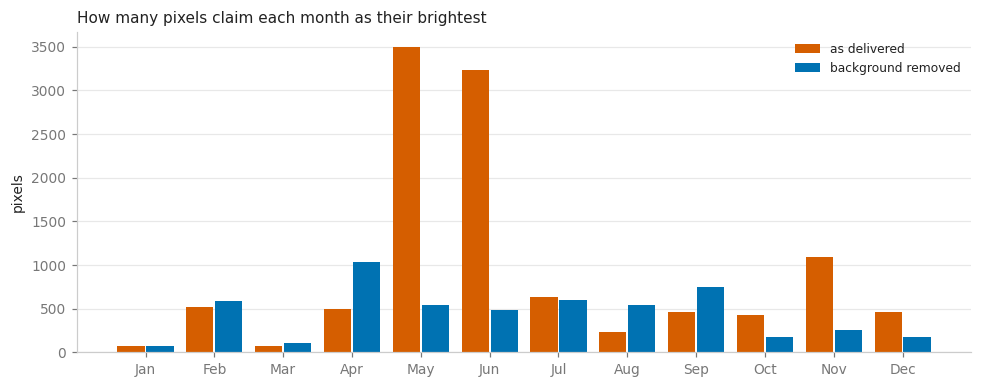

In [14]:
both = pd.DataFrame({'as delivered': naive_counts, 'background removed': counts})
width = 0.42
x = np.arange(12)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(x - width / 2, both['as delivered'], width * 0.94, color=HUES[1],
       label='as delivered')
ax.bar(x + width / 2, both['background removed'], width * 0.94, color=HUES[0],
       label='background removed')
ax.set_xticks(x)
ax.set_xticklabels(SHORT)
ax.set_ylabel('pixels')
ax.set_title('How many pixels claim each month as their brightest', loc='left',
             fontsize=10)
ax.legend(frameon=False, fontsize=8)
ax.grid(axis='y', lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()

The May–June block collapses, and what is left is a landscape instead of a stripe.

Two numbers deserve reading carefully. The share of lit pixels peaking in May or June falls
by about two thirds. And the number of lit pixels itself falls by more than half: thousands
of pixels that cleared the 0.5 nW/cm²/sr threshold before do not clear it now. They never
held any light — they held the June residue, and the threshold was measuring the artefact.

That is the general lesson of this notebook, and it has nothing to do with nighttime lights
in particular. **A threshold applied to an uncorrected quantity selects the correction.**

## 5. Does the calendar repeat?

A median over twelve years hides whether those years agreed. `get_peak_period()` run once
per corrected year gives twelve answers per pixel, and `get_peak_statistics()` summarises
them the way a month has to be summarised — as a direction on a circle, because the
ordinary mean of December and January is June.

In [15]:
peaks = ee.ImageCollection([
    monthly.get_peak_period(composite=image.rename(MONTHS), mask_below=0.5)
    for image in corrected])

stats = monthly.get_peak_statistics(peaks=peaks, min_years=8)
stats.bandNames().getInfo()

['circular_mean', 'concentration', 'n_years']

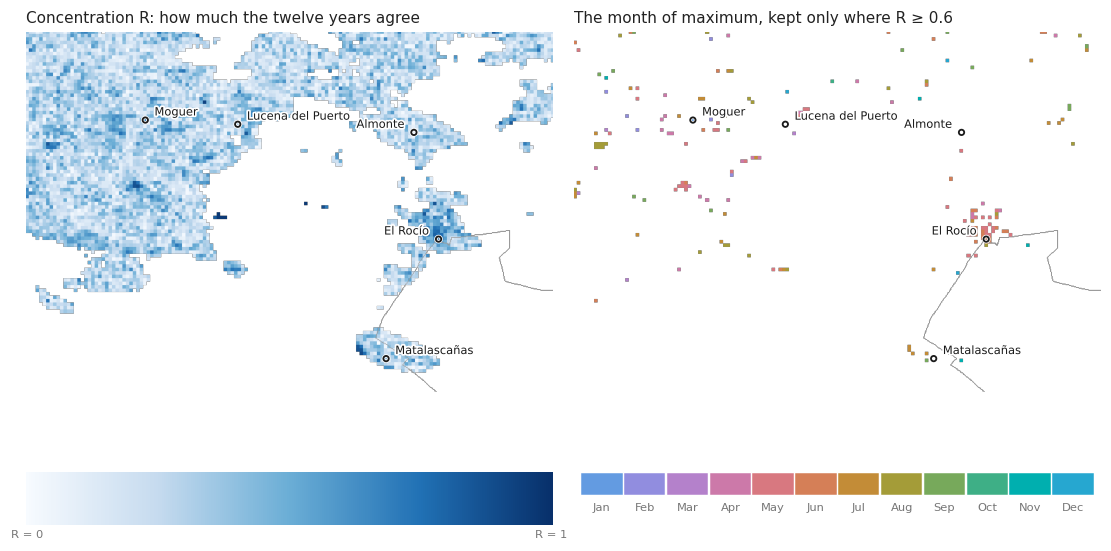

In [16]:
R_VIS = {'min': 0, 'max': 1,
         'palette': ['f7fbff', 'c6dbef', '6baed6', '2171b5', '08306b']}
reliable = peak.select('peak_period').updateMask(
    stats.select('concentration').gte(0.6))

panels = [(thumbnail(stats.select('concentration'), R_VIS),
           'Concentration R: how much the twelve years agree'),
          (thumbnail(reliable, MONTH_VIS),
           'The month of maximum, kept only where R ≥ 0.6')]

fig = plt.figure(figsize=(12.6, 6.6))
grid = fig.add_gridspec(2, 2, height_ratios=[16, 1.7], hspace=0.05, wspace=0.04)
for column, (array, title) in enumerate(panels):
    ax = fig.add_subplot(grid[0, column])
    ax.set_facecolor('#f2f2f0')
    ax.imshow(array)
    label_places(ax, array)
    ax.set_title(title, loc='left', fontsize=10)
    ax.axis('off')
month_legend(fig.add_subplot(grid[1, 1]))

bar = fig.add_subplot(grid[1, 0])
ramp = mpl.colors.LinearSegmentedColormap.from_list(
    'R', ['#' + colour for colour in R_VIS['palette']])
bar.imshow(np.linspace(0, 1, 256).reshape(1, -1), aspect='auto', cmap=ramp)
bar.set_yticks([])
bar.set_xticks([0, 255])
bar.set_xticklabels(['R = 0', 'R = 1'])
bar.tick_params(length=0, labelsize=7.5, colors=MUTED)
for spine in bar.spines.values():
    spine.set_visible(False)

R is the resultant length of the twelve yearly directions: 1 means every year peaked in the
same month, 0 means they point in every direction and the mean month is an artefact of
averaging. The right-hand map keeps only the pixels whose years agree, and it is much
emptier than the map of section 4 — most of the countryside has a *typical* peak month that
no individual year particularly respects.

Where R survives is where something in the calendar is real.

## 6. Reading the calendar, place by place

In [17]:
def profile(geometry, image=None):
    # corrected monthly climatology of one place
    values = (typical if image is None else image).reduceRegion(
        ee.Reducer.mean(), geometry, 463.83, maxPixels=1e9).getInfo()
    return pd.Series([values[month] for month in MONTHS], index=SHORT)


profiles = pd.DataFrame({name: profile(ee.Geometry.Point(list(coords)).buffer(900))
                         for name, coords in PLACES.items()})
shape = profiles / profiles.mean()
shape.round(2)

,Almonte,El Rocío,Matalascañas,Moguer,Lucena del Puerto
Jan,0.95,0.93,0.95,1.18,0.96
Feb,0.98,0.92,0.99,1.25,0.96
Mar,1.00,0.87,1.00,1.16,0.97
Apr,0.97,0.90,1.04,1.05,1.04
May,1.05,1.21,1.04,0.95,1.02
Jun,1.03,1.28,1.04,0.90,1.01
Jul,1.09,1.05,1.06,0.89,1.09
Aug,1.03,1.10,1.07,0.92,1.06
Sep,0.99,0.99,0.98,1.04,1.03
Oct,0.91,0.93,0.96,0.84,0.92


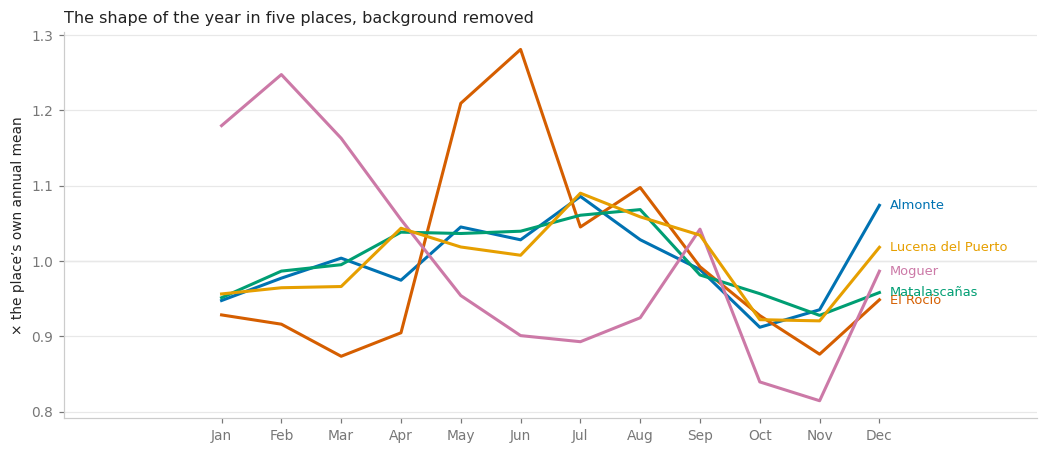

In [18]:
fig, ax = plt.subplots(figsize=(9.6, 4.2))
for (name, values), hue in zip(shape.items(), HUES):
    ax.plot(SHORT, values, '-', lw=2, color=hue)
    ax.annotate(name, (11, values.iloc[-1]), xytext=(7, 0), textcoords='offset points',
                fontsize=8.5, color=hue, va='center')
ax.axhline(1, color='#cccccc', lw=0.8, zorder=0)
ax.set_ylabel('× the place’s own annual mean')
ax.set_title('The shape of the year in five places, background removed', loc='left',
             fontsize=10.5)
ax.grid(axis='y', lw=0.8)
ax.set_axisbelow(True)
ax.margins(x=0.24)
plt.tight_layout()

In [19]:
summary = pd.DataFrame(
    {name: stats.reduceRegion(ee.Reducer.mean(),
                              ee.Geometry.Point(list(coords)).buffer(900),
                              463.83, maxPixels=1e9).getInfo()
     for name, coords in PLACES.items()}).T
summary['peak month'] = [SHORT[int(round(value)) % 12 - 1] if pd.notna(value) else '—'
                         for value in summary['circular_mean']]
summary = summary.rename(columns={'circular_mean': 'circular mean (month no.)',
                                  'concentration': 'R', 'n_years': 'years'})
summary[['circular mean (month no.)', 'peak month', 'R', 'years']].round(2)

,circular mean (month no.),peak month,R,years
Almonte,6.58,Jul,0.21,12.00
El Rocío,5.39,May,0.58,12.00
Matalascañas,5.55,Jun,0.30,11.97
Moguer,7.08,Jul,0.29,12.00
Lucena del Puerto,7.25,Jul,0.27,11.98


Four nearly flat lines, and one that is not — but the one that is not is not the one the
notebook is looking for.

**Almonte**, **Matalascañas** and **Lucena del Puerto** move within about ±9% of their own
annual means. **El Rocío** rises 21% in May and 28% in June, which is the Romería that
notebook 11 measured against the two years it was cancelled.

And then there is **Moguer**, which has the largest swing of all five — 1.25 in February
against 0.81 in November, a range of ±22% — and it swings in exactly the direction a berry
campaign would produce: high from December to March, low from July to November. That is a
lead worth following, and the rest of the notebook follows it.

One warning before we do. The table above gives Moguer a circular mean of 7.1 (July) with
R = 0.29, which contradicts the curve. There is no bug: **R measures whether the argmax
agrees between years, not whether the shape does.** A broad winter plateau has no stable
single maximum — January, February and March take turns — so R collapses even if every
year has the same plateau. For a signal that is a season rather than an event, R is the
wrong test, and the right one is the size of the seasonal difference, measured year by
year. That is section 7.

## 7. The map the question actually needs

Averaging a town-sized circle is the wrong instrument anyway. A camp of a few hundred
people occupies a hectare or two; a single VIIRS pixel is about twenty-two. If a place
switches on for the picking season it does so in *one* pixel, and any average over its
surroundings buries it.

So the berry belt gets its own map, at its own scale, and a second one that asks the
seasonal question directly: **how much brighter is a pixel during the campaign than after
it?** December to June against August to October, in nW/cm²/sr — orange where the light
arrives with the picking, blue where it arrives with the summer.

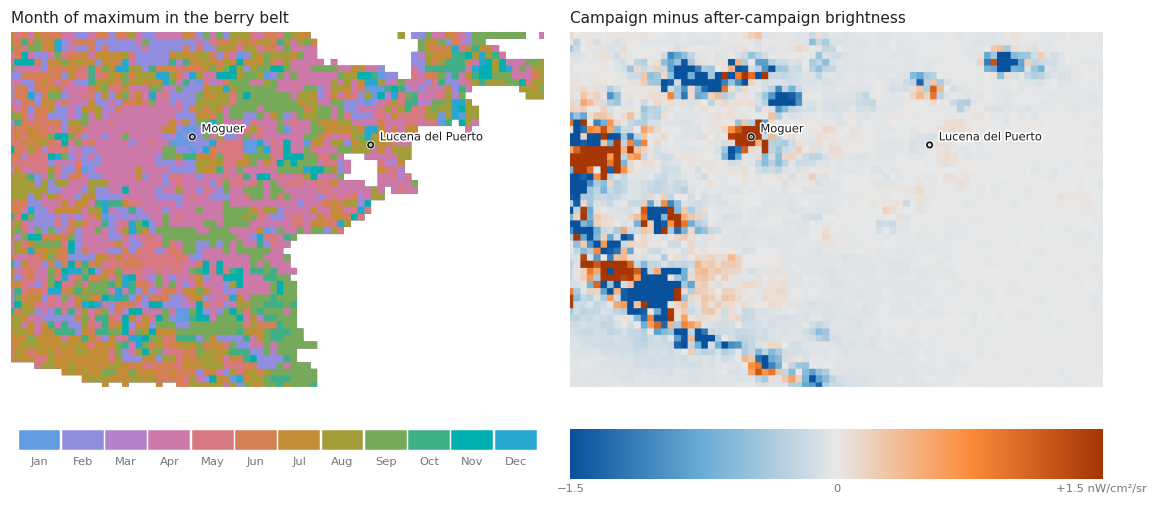

In [20]:
BELT = ee.Geometry.Rectangle([-6.95, 37.12, -6.62, 37.34])
BELT_BOX = (-6.95, 37.12, -6.62, 37.34)

CAMPAIGN = ['december', 'january', 'february', 'march', 'april', 'may', 'june']
AFTER = ['august', 'september', 'october']


def campaign_rise(image):
    # brighter during the picking season than after it, in nW/cm²/sr
    return (image.select(CAMPAIGN).reduce(ee.Reducer.mean())
            .subtract(image.select(AFTER).reduce(ee.Reducer.mean())).rename('rise'))


rise = campaign_rise(typical)
level = typical.reduce(ee.Reducer.mean()).rename('level')

DIVERGING = {'min': -1.5, 'max': 1.5,
             'palette': ['08519c', '6baed6', 'e8e8e8', 'fd8d3c', 'a63603']}

panels = [(thumbnail(peak.select('peak_period').clip(BELT), MONTH_VIS, region=BELT,
                     dimensions=820, outline=False),
           'Month of maximum in the berry belt'),
          (thumbnail(rise.clip(BELT), DIVERGING, region=BELT, dimensions=820,
                     outline=False),
           'Campaign minus after-campaign brightness')]

fig = plt.figure(figsize=(12.8, 5.6))
grid = fig.add_gridspec(2, 2, height_ratios=[14, 1.7], hspace=0.06, wspace=0.05)
for column, (array, title) in enumerate(panels):
    ax = fig.add_subplot(grid[0, column])
    ax.set_facecolor('#f2f2f0')
    ax.imshow(array)
    label_places(ax, array, region=BELT_BOX)
    ax.set_title(title, loc='left', fontsize=10)
    ax.axis('off')
month_legend(fig.add_subplot(grid[1, 0]))

bar = fig.add_subplot(grid[1, 1])
ramp = mpl.colors.LinearSegmentedColormap.from_list(
    'rise', ['#' + colour for colour in DIVERGING['palette']])
bar.imshow(np.linspace(0, 1, 256).reshape(1, -1), aspect='auto', cmap=ramp)
bar.set_yticks([])
bar.set_xticks([0, 128, 255])
bar.set_xticklabels(['−1.5', '0', '+1.5 nW/cm²/sr'])
bar.tick_params(length=0, labelsize=7.5, colors=MUTED)
for spine in bar.spines.values():
    spine.set_visible(False)

There *is* orange, and it is not scattered at random: it clusters on Moguer and on the
farming ground west of it. Taken at face value, that is the answer the notebook set out to
find. So the strongest of those pixels are pulled out and looked at one at a time.

In [21]:
# GHS_BUILT_S 2020 gives built surface in m² inside each 100 m cell; averaged onto
# the VIIRS grid it separates a town from a rural pixel
ghsl = (ee.ImageCollection('JRC/GHSL/P2023A/GHS_BUILT_S')
        .filter(ee.Filter.eq('system:index', '2020')).first().select('built_surface'))
built = (ghsl.reduceResolution(ee.Reducer.mean(), maxPixels=1024)
         .reproject(crs=ghsl.projection(), scale=500).rename('built'))

rural = rise.gt(0.3).And(level.gt(0.15)).And(built.unmask(0).lt(1200))

found = (rise.addBands([level, built]).updateMask(rural)
         .reproject(crs='EPSG:4326', scale=463.83)
         .sample(region=BELT, scale=463.83, geometries=True, numPixels=20000, seed=1))

risers = pd.DataFrame([{'lon': round(f['geometry']['coordinates'][0], 4),
                        'lat': round(f['geometry']['coordinates'][1], 4),
                        **f['properties']} for f in found.getInfo()['features']])
risers = risers.sort_values('rise', ascending=False).reset_index(drop=True)
print('%d rural pixels in the belt brighten by more than 0.3 nW/cm²/sr' % len(risers))
risers.head(8)[['lat', 'lon', 'level', 'rise', 'built']].round(2)

85 rural pixels in the belt brighten by more than 0.3 nW/cm²/sr


,lat,lon,level,rise,built
0,37.27,-6.84,22.85,6.84,1045.00
1,37.28,-6.85,16.85,6.39,51.84
2,37.23,-6.89,77.45,4.26,510.16
3,37.27,-6.85,12.18,4.06,8.44
4,37.28,-6.84,22.08,4.02,505.40
5,37.29,-6.94,80.79,3.49,823.88
6,37.25,-6.93,23.51,2.98,103.44
7,37.26,-6.92,18.18,2.88,63.44


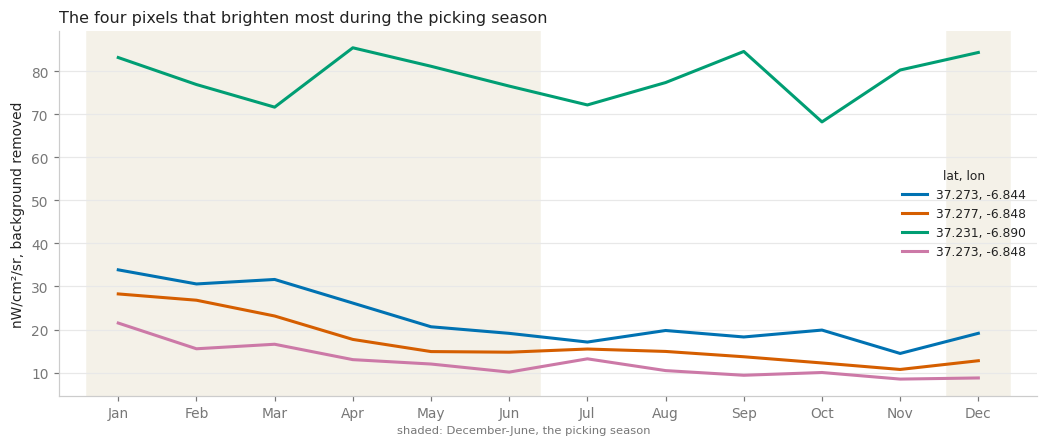

In [22]:
top = risers.head(4)
pixels = pd.DataFrame(
    {'%.3f, %.3f' % (row.lat, row.lon):
     profile(ee.Geometry.Point([row.lon, row.lat]).buffer(250))
     for row in top.itertuples()})

fig, ax = plt.subplots(figsize=(9.6, 4)) 
for span in [(-0.4, 5.4), (10.6, 11.4)]:               # Dec-Jun wraps the axis
    ax.axvspan(*span, color='#f4f1e8', zorder=0)
for (name, values), hue in zip(pixels.items(), HUES):
    ax.plot(SHORT, values, '-', lw=2, color=hue, label=name)
ax.set_ylabel('nW/cm²/sr, background removed')
ax.set_title('The four pixels that brighten most during the picking season', loc='left',
             fontsize=10.5)
ax.legend(frameon=False, fontsize=8, title='lat, lon', title_fontsize=8)
ax.grid(axis='y', lw=0.8)
ax.set_axisbelow(True)
ax.margins(x=0.03)
plt.tight_layout()
fig.text(0.5, 0.005, 'shaded: December-June, the picking season', ha='center',
         fontsize=7.5, color=MUTED)
plt.show()

The shapes are plausible. They are also, all four, computed from a median over twelve
years, and a median over twelve years quietly assumes that the place was the same place in
all twelve.

The test that settles it is to stop averaging the years together. The campaign difference
is computed **separately for every year**, for each of the eight towns of the belt: if the
berry season lights anything up, the sign of that difference should be the same year after
year.

In [23]:
TOWNS = {'Moguer': (-6.8378, 37.2753), 'Palos': (-6.8931, 37.2283),
         'Lucena del Puerto': (-6.7272, 37.2703), 'Bonares': (-6.6822, 37.3239),
         'Rociana': (-6.6000, 37.3070), 'Almonte': (-6.5164, 37.2606),
         'El Rocío': (-6.4869, 37.1332), 'Matalascañas': (-6.5497, 36.9906)}

rows = []
for image, year in zip(corrected, YEARS):
    yearly = campaign_rise(image)
    for name, coords in TOWNS.items():
        rows.append(ee.Feature(None, {'year': year, 'town': name}).set(
            yearly.reduceRegion(ee.Reducer.mean(),
                                ee.Geometry.Point(list(coords)).buffer(900),
                                463.83, maxPixels=1e9)))
yearly_rise = pd.DataFrame([f['properties'] for f in
                            ee.FeatureCollection(rows).getInfo()['features']])
yearly_rise = yearly_rise.pivot(index='year', columns='town', values='rise')[list(TOWNS)]

agreement = pd.DataFrame({'years brighter in campaign': (yearly_rise > 0).sum(),
                          'out of': yearly_rise.notna().sum(),
                          'median (nW/cm²/sr)': yearly_rise.median().round(2)})
agreement

,years brighter in campaign,out of,median (nW/cm²/sr)
town,,,
Moguer,5,12,-0.46
Palos,5,12,-1.29
Lucena del Puerto,4,12,-0.02
Bonares,3,12,-0.57
Rociana,4,12,-0.64
Almonte,6,12,0.81
El Rocío,7,12,0.11
Matalascañas,4,12,-0.16


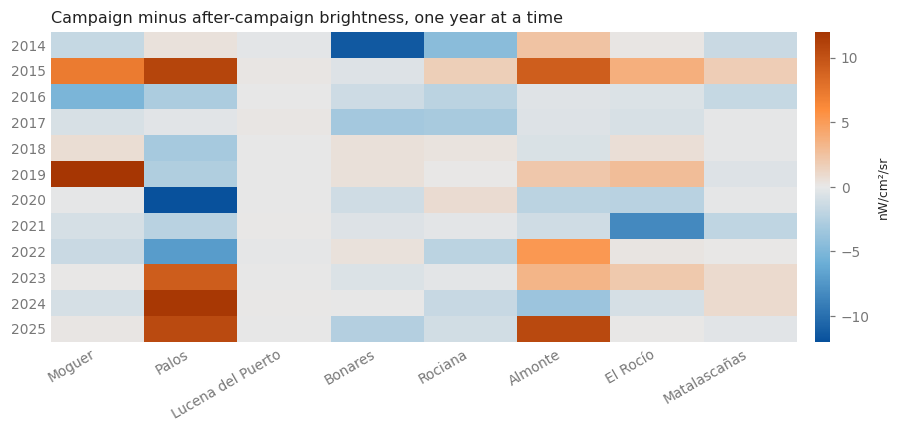

In [24]:
limit = 12
fig, ax = plt.subplots(figsize=(8.8, 4))
image = ax.imshow(yearly_rise.values, cmap=ramp, aspect='auto', vmin=-limit, vmax=limit)
ax.set_xticks(range(len(TOWNS)))
ax.set_xticklabels(list(TOWNS), rotation=30, ha='right')
ax.set_yticks(range(len(yearly_rise)))
ax.set_yticklabels(yearly_rise.index)
ax.set_title('Campaign minus after-campaign brightness, one year at a time', loc='left',
             fontsize=10.5)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
colour_bar = fig.colorbar(image, ax=ax, pad=0.02)
colour_bar.set_label('nW/cm²/sr', fontsize=8)
colour_bar.outline.set_visible(False)
plt.tight_layout()

The lead dies here. No town has the same sign in more than seven years out of twelve, and a
fair coin reaches seven out of twelve about two times in five. Moguer, the one that looked
most like a campaign, is positive in five years and negative in seven, and its median
difference is **negative**. The whole pattern is two or three enormous years — Moguer 2019
at +13.7, Palos 2020 at −18.6 and 2024 at +11.8 — sitting on top of a column of values near
zero.

Those outliers are not noise. They are the reason the median over years lied, and they have
a cause that is worth a section of its own.

## 8. The towns changed, and that is the real signal

In [25]:
rows = []
for image, year in zip(corrected, YEARS):
    annual = image.reduce(ee.Reducer.mean()).rename('mean')
    for name, coords in TOWNS.items():
        rows.append(ee.Feature(None, {'year': year, 'town': name}).set(
            annual.reduceRegion(ee.Reducer.mean(),
                                ee.Geometry.Point(list(coords)).buffer(900),
                                463.83, maxPixels=1e9)))
annual = pd.DataFrame([f['properties'] for f in
                       ee.FeatureCollection(rows).getInfo()['features']])
annual = annual.pivot(index='year', columns='town', values='mean')[list(TOWNS)]

change = (annual.loc[2023:2025].mean() / annual.loc[2014:2016].mean()).round(2)
change.sort_values().to_frame('2023-25 brightness ÷ 2014-16').T

town,Moguer,Bonares,Lucena del Puerto,Matalascañas,Palos,Rociana,El Rocío,Almonte
2023-25 brightness ÷ 2014-16,0.36,0.41,0.83,0.91,0.98,1.02,1.3,1.66


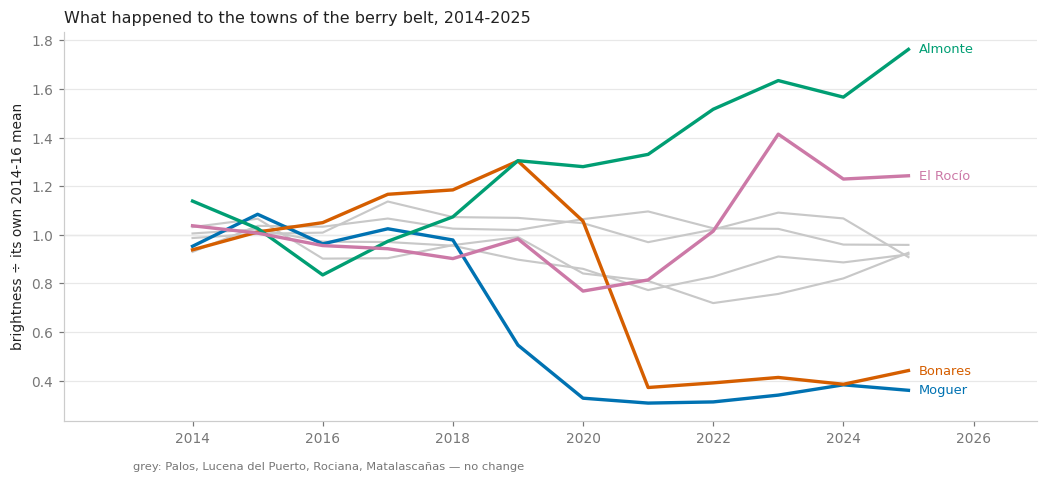

In [26]:
MOVERS = {'Moguer': HUES[0], 'Bonares': HUES[1], 'Almonte': HUES[2],
          'El Rocío': HUES[3]}

fig, ax = plt.subplots(figsize=(9.6, 4.4))
for town in annual:
    values = annual[town] / annual[town].loc[2014:2016].mean()
    hue = MOVERS.get(town, '#c8c8c8')
    ax.plot(annual.index, values, '-', lw=2.2 if town in MOVERS else 1.4, color=hue,
            zorder=3 if town in MOVERS else 1)
    if town in MOVERS:
        ax.annotate(town, (annual.index[-1], values.iloc[-1]), xytext=(7, 0),
                    textcoords='offset points', fontsize=8.5, color=hue, va='center')
ax.axhline(1, color='#cccccc', lw=0.8, zorder=0)
ax.set_ylabel('brightness ÷ its own 2014-16 mean')
ax.set_title('What happened to the towns of the berry belt, 2014-2025', loc='left',
             fontsize=10.5)
ax.grid(axis='y', lw=0.8)
ax.set_axisbelow(True)
ax.margins(x=0.18)
fig.text(0.13, 0.02, 'grey: Palos, Lucena del Puerto, Rociana, Matalascañas — no change',
         fontsize=7.5, color=MUTED)
plt.tight_layout(rect=(0, 0.04, 1, 1))

Two towns lost roughly two thirds of their brightness, each in a single year: **Moguer
between 2018 and 2020** and **Bonares between 2020 and 2021**. Two others gained — Almonte
by two thirds over the record, El Rocío by a third. The four that are flat stay flat.

Nobody switched a town off. What a step like that records is a **lighting refit**: sodium
lamps replaced with LEDs. VIIRS's day/night band is nearly blind to blue, and LED spectra
move a large part of their power into exactly the range the sensor does not measure, so a
street can be relit to the same or better standard on the ground and lose two thirds of its
radiance from orbit. It is the best-known bias in the whole nighttime-lights literature,
and here it is, twice, inside one county.

This also closes a loose end left open in notebook 11, which noticed El Rocío's ordinary
nights rising from about 25 to about 35 nW/cm²/sr and said the record could not say what had
changed. Seen next to its neighbours it can: two towns of the same county went down by the
same kind of step at a different date, and two went up. These are municipal decisions about
lamps, and they are an order of magnitude larger than any season.

Which is the answer to the question this notebook asked. **No pixel of the Doñana berry belt
shows a repeatable brightening during the picking season.** The candidates the map offered
were towns whose lighting changed between one year and the next, and the change was large
enough to survive a twelve-year median and pose as a season.

That is a floor, not a shrug, and it can be quoted. The seasonal difference this analysis
can resolve in the belt is a few tenths of a nW/cm²/sr against year-to-year steps of tens.
A settlement of a few hundred people, largely off-grid, lighting itself with fires, gas and
the occasional generator, is far below that inside a pixel of twenty-two hectares that also
contains greenhouses, a road and the glow of the nearest town. Seeing it needs resolution,
not processing: SDGSAT-1's glimmer imager at 40 m, or the astronaut photographs taken from
the ISS, resolve lit clusters of that size. VIIRS does not.

## 9. What to take away

**A peak-month map is an artefact detector.** Asking "when" instead of "how much" makes
instrumental seasonality impossible to ignore: a quantity with no reason to have a season
still had one, and the map painted it across the whole landscape in a single colour. The
same map built on reflectance would expose a sensor's angular effects the same way.

**Calibrate against something that must be constant.** Three unlit surfaces — ocean, pine,
marsh — with nothing in common but the sky agreed on the shape of the residue to within a
few per cent. That agreement is what turns "this looks like an artefact" into a correction
that can be subtracted, and it costs three `reduceRegion` calls.

**A threshold on an uncorrected quantity selects the correction.** More than half of the
pixels that passed `mask_below=0.5` before the subtraction did not pass it after: what they
had cleared the threshold with was the June residue.

**R tests the argmax, not the shape.** `get_peak_statistics()` answers "do the years peak in
the same month", which is the right question for an event like the Romería and the wrong one
for a plateau like a harvest season. When the signal is a season, test the size of the
seasonal difference year by year instead.

**A median over years assumes the place did not change.** Two of eight towns here lost two
thirds of their light to a lamp refit, and the median over twelve years turned that step
into a plausible, entirely false, agricultural season. Any multi-year composite of any index
carries the same assumption; this record just makes the violation easy to see.

**A negative result is a measurement when you can say where the floor is.** VIIRS does not
see the seasonal settlements of the berry belt, and this notebook can say by roughly how
much it misses them and which instrument would not.

---

*Companion notebooks:* [Nighttime Lights (Seville)](09_nighttime_lights.ipynb) introduces the
three collections and `get_peak_period()`;
[Joining DMSP and VIIRS (Doñana)](11_donana_lights.ipynb) crosses the 2013 sensor change and
measures the Romería against the two years it was cancelled.